# General Parameters

In [1]:
### Load Python Lib##### 
### plot_FFcompsr_Q2max.py
### Plot form factor ratios vs. Q^2max for fits w/, w/o sum rules with stat errors.
########
import numpy as np
from math import *
import matplotlib.pyplot as plt
from matplotlib import rc
from matplotlib.ticker import FixedLocator, MultipleLocator, FormatStrFormatter
import os, sys, traceback

#very import to enable this so the plots can be showed in the page
get_ipython().magic(u'matplotlib inline')

# Use LaTeX font.
plt.rc('text', usetex=True)
plt.rc('font',**{'family':'serif','serif':['Computer Modern Roman'],'size':20})

import matplotlib.font_manager as font_manager
font_prop = font_manager.FontProperties( size=12)

In [2]:
## Input Parameters
Q2max = 1000
Q2str = str(Q2max)
Q2plot =10000
kmax = 12
#kmax=int(sys.argv[1])

fitdata = 'world'
#Q2max = int(raw_input('Max Q2 Fit =  '))
#Q2plot = float(raw_input('Max Q2 Plot = '))
#kmax = int(raw_input('Max Z = '))

bnd = '5'
mod = 't0fix7'
#mod='t0zero'
#mode=sys.argv[2]
GM0 = 2.79284356
GE0 = 1

# Load Data

In [3]:
## Dipole FF
Lambda2 = 0.71
GE0 = 1
GM0 = 2.792847356
GEp0 = 1
GMp0 = 2.792847356
GEn0 = 1
GMn0 = -1.91304272
def GD(Q2):
    return 1./(1+Q2/Lambda2)**2


## Load World+Pol+Mainz Sum-Rules baseline Fitting Results

In [4]:
fit_date='may23'

In [5]:
##Load Q2max=1000 Fitting results#{{{
folder = '../%s_all_FF/z'%fit_date+str(kmax) # folder containing central fits
#filename=folder+'/Round6_all_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'.dat'
filename=folder+'/out_all_sumrules_leastsq_Q2'+Q2str+'_z'+str(kmax)+'_gb'+bnd+'_'+mod+'.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2 = np.zeros(N, dtype=float)
Z = np.zeros(N, dtype=float)
GE_fit = np.zeros(N, dtype=float)
GE_pos = np.zeros(N, dtype=float)
GE_neg = np.zeros(N, dtype=float)
GM_fit = np.zeros(N, dtype=float)
GM_pos = np.zeros(N, dtype=float)
GM_neg = np.zeros(N, dtype=float)
GE_fit_rat = np.zeros(N, dtype=float)
GE_pos_rat = np.zeros(N, dtype=float)
GE_neg_rat = np.zeros(N, dtype=float)
GM_fit_rat = np.zeros(N, dtype=float)
GM_pos_rat = np.zeros(N, dtype=float)
GM_neg_rat = np.zeros(N, dtype=float)
GEGM_fit_rat = np.zeros(N, dtype=float)
GEGM_pos_rat = np.zeros(N, dtype=float)
GEGM_neg_rat = np.zeros(N, dtype=float)
GE_err = np.zeros(N, dtype=float)
GM_err = np.zeros(N, dtype=float)
GEGM_err = np.zeros(N, dtype=float)
GE_err_rat = np.zeros(N, dtype=float)
GM_err_rat = np.zeros(N, dtype=float)
GEd = np.zeros(N, dtype=float)
GMd = np.zeros(N, dtype=float)

for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2[i]=float(values[0])
    Z[i]=float(values[1])

    GE_fit[i]=float(values[2])
    GE_pos[i]=float(values[2])+abs(float(values[3]))
    GE_neg[i]=float(values[2])-abs(float(values[3]))
    GM_fit[i]=float(values[4])
    GM_pos[i]=float(values[4])+abs(float(values[5]))
    GM_neg[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat[i]=float(values[6])
    GE_pos_rat[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat[i]=float(values[8])
    GM_pos_rat[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat[i]=float(values[10])+abs(GEGM_err1)
    GEGM_neg_rat[i]=float(values[10])-abs(GEGM_err1)
 
    GEd[i] = GD(Q2[i]) * GE0
    GMd[i] = GD(Q2[i]) * GM0
    GE_err[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err[i] = GEGM_err1/float(values[10])
    GE_err_rat[i] = abs(float(values[7]) ) #/ abs(float(values[2]))
    GM_err_rat[i] = abs(float(values[9]) ) #/ abs(float(values[4]))
    
values = fitlines[2016].split()
erad = float(values[0])
derad = float(values[1])
mrad = float(values[2])
dmrad = float(values[3])

values = fitlines[2015].split()
ndof = float(values[0])
num_tot = float(values[1])
num_Mainz = float(values[2])
num_world = float(values[3])
num_pol = float(values[4])

values = fitlines[2014].split()
redchi2 = float(values[0])
chi2 = float(values[1])
chi2xsMainz = float(values[2])
chi2xsworld = float(values[3])
chi2pol = float(values[4])
chi2gecoef = float(values[5])
chi2gmcoef = float(values[6])
chi2csyst = float(values[7])
chi2NMainz = float(values[8])
chi2Nworld = float(values[9])
chi2gefake= float(values[10])
chi2gmfake= float(values[11])
chi2gefakeHQ= float(values[12])
chi2gmfakeHQ= float(values[13])

#}}}

file exist ../may23_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7.dat


## Fit Load World+Pol Sum-Rules baseline Fitting Results

In [6]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'world'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../%s_%s_FF/z'%(fit_date,comp)+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_WP = np.zeros(N, dtype=float)
GE_fit_WP = np.zeros(N, dtype=float)
GE_pos_WP = np.zeros(N, dtype=float)
GE_neg_WP = np.zeros(N, dtype=float)
GM_fit_WP = np.zeros(N, dtype=float)
GM_pos_WP = np.zeros(N, dtype=float)
GM_neg_WP = np.zeros(N, dtype=float)
GE_fit_rat_WP = np.zeros(N, dtype=float)
GE_pos_rat_WP = np.zeros(N, dtype=float)
GE_neg_rat_WP = np.zeros(N, dtype=float)
GM_fit_rat_WP = np.zeros(N, dtype=float)
GM_pos_rat_WP = np.zeros(N, dtype=float)
GM_neg_rat_WP = np.zeros(N, dtype=float)
GEGM_fit_rat_WP = np.zeros(N, dtype=float)
GEGM_pos_rat_WP = np.zeros(N, dtype=float)
GEGM_neg_rat_WP = np.zeros(N, dtype=float)
GE_err_WP = np.zeros(N, dtype=float)
GM_err_WP = np.zeros(N, dtype=float)
GEGM_err_WP = np.zeros(N, dtype=float)
GE_err_rat_WP = np.zeros(N, dtype=float)
GM_err_rat_WP = np.zeros(N, dtype=float)
GEd_WP = np.zeros(N, dtype=float)
GMd_WP = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_WP[i]=float(values[0])
    GE_fit_WP[i]=float(values[2])
    GE_pos_WP[i]=float(values[2])+abs(float(values[3]))
    GE_neg_WP[i]=float(values[2])-abs(float(values[3]))
    GM_fit_WP[i]=float(values[4])
    GM_pos_WP[i]=float(values[4])+abs(float(values[5]))
    GM_neg_WP[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_WP[i]=float(values[6])
    GE_pos_rat_WP[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_WP[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_WP[i]=float(values[8])
    GM_pos_rat_WP[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_WP[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_WP[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_WP[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_WP[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_WP[i] = GD(Q2_WP[i]) * GE0
    GMd_WP[i] = GD(Q2_WP[i]) * GM0
    GE_err_WP[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_WP[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_WP[i] = GEGM_err_n1/float(values[10])
    GE_err_rat_WP[i] = abs(float(values[7]) ) 
    GM_err_rat_WP[i] = abs(float(values[9]) ) 
    
values = fitlines[2016].split()
erad_WP = float(values[0])
derad_WP = float(values[1])
mrad_WP = float(values[2])
dmrad_WP = float(values[3])

values = fitlines[2015].split()
ndof_WP = float(values[0])
num_tot_WP = float(values[1])
num_Mainz_WP = float(values[2])
num_world_WP = float(values[3])
num_pol_WP = float(values[4])

values = fitlines[2014].split()
redchi2_WP = float(values[0])
chi2_WP = float(values[1])
chi2xsMainz_WP = float(values[2])
chi2xsworld_WP = float(values[3])
chi2pol_WP = float(values[4])
chi2gecoef_WP = float(values[5])
chi2gmcoef_WP = float(values[6])
chi2csyst_WP = float(values[7])
chi2NMainz_WP = float(values[8])
chi2Nworld_WP = float(values[9])
chi2gefake_WP = float(values[10])
chi2gmfake_WP = float(values[11])
chi2gefakeHQ_WP = float(values[12])
chi2gmfakeHQ_WP = float(values[13])

#}}}

file exist ../may23_world_FF/z12/out_world_sumrules_leastsq_Q21000_z12_gb5_t0fix7.dat


## Fit Load World+Pol Sum-Rules baseline Fitting Results w/o radius contraint

In [7]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'world'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../%s_%s_FF/z'%(fit_date,comp)+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noRad.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_WP_noRad = np.zeros(N, dtype=float)
GE_fit_WP_noRad = np.zeros(N, dtype=float)
GE_pos_WP_noRad = np.zeros(N, dtype=float)
GE_neg_WP_noRad = np.zeros(N, dtype=float)
GM_fit_WP_noRad = np.zeros(N, dtype=float)
GM_pos_WP_noRad = np.zeros(N, dtype=float)
GM_neg_WP_noRad = np.zeros(N, dtype=float)
GE_fit_rat_WP_noRad = np.zeros(N, dtype=float)
GE_pos_rat_WP_noRad = np.zeros(N, dtype=float)
GE_neg_rat_WP_noRad = np.zeros(N, dtype=float)
GM_fit_rat_WP_noRad = np.zeros(N, dtype=float)
GM_pos_rat_WP_noRad = np.zeros(N, dtype=float)
GM_neg_rat_WP_noRad = np.zeros(N, dtype=float)
GEGM_fit_rat_WP_noRad = np.zeros(N, dtype=float)
GEGM_pos_rat_WP_noRad = np.zeros(N, dtype=float)
GEGM_neg_rat_WP_noRad = np.zeros(N, dtype=float)
GE_err_WP_noRad = np.zeros(N, dtype=float)
GM_err_WP_noRad = np.zeros(N, dtype=float)
GEGM_err_WP_noRad = np.zeros(N, dtype=float)
GE_err_rat_WP_noRad = np.zeros(N, dtype=float)
GM_err_rat_WP_noRad = np.zeros(N, dtype=float)
GEd_WP_noRad = np.zeros(N, dtype=float)
GMd_WP_noRad = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_WP_noRad[i]=float(values[0])
    GE_fit_WP_noRad[i]=float(values[2])
    GE_pos_WP_noRad[i]=float(values[2])+abs(float(values[3]))
    GE_neg_WP_noRad[i]=float(values[2])-abs(float(values[3]))
    GM_fit_WP_noRad[i]=float(values[4])
    GM_pos_WP_noRad[i]=float(values[4])+abs(float(values[5]))
    GM_neg_WP_noRad[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_WP_noRad[i]=float(values[6])
    GE_pos_rat_WP_noRad[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_WP_noRad[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_WP_noRad[i]=float(values[8])
    GM_pos_rat_WP_noRad[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_WP_noRad[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_WP_noRad[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_WP_noRad[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_WP_noRad[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_WP_noRad[i] = GD(Q2_WP_noRad[i]) * GE0
    GMd_WP_noRad[i] = GD(Q2_WP_noRad[i]) * GM0
    GE_err_WP_noRad[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_WP_noRad[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_WP_noRad[i] = GEGM_err_n1/float(values[10])
    GE_err_rat_WP_noRad[i] = abs(float(values[7]) ) 
    GM_err_rat_WP_noRad[i] = abs(float(values[9]) ) 
    
values = fitlines[2016].split()
erad_WP_noRad = float(values[0])
derad_WP_noRad = float(values[1])
mrad_WP_noRad = float(values[2])
dmrad_WP_noRad = float(values[3])

values = fitlines[2015].split()
ndof_WP_noRad = float(values[0])
num_tot_WP_noRad = float(values[1])
num_Mainz_WP_noRad = float(values[2])
num_world_WP_noRad = float(values[3])
num_pol_WP_noRad = float(values[4])

values = fitlines[2014].split()
redchi2_WP_noRad = float(values[0])
chi2_WP_noRad = float(values[1])
chi2xsMainz_WP_noRad = float(values[2])
chi2xsworld_WP_noRad = float(values[3])
chi2pol_WP_noRad = float(values[4])
chi2gecoef_WP_noRad = float(values[5])
chi2gmcoef_WP_noRad = float(values[6])
chi2csyst_WP_noRad = float(values[7])
chi2NMainz_WP_noRad = float(values[8])
chi2Nworld_WP_noRad = float(values[9])
chi2gefake_WP_noRad = float(values[10])
chi2gmfake_WP_noRad = float(values[11])
chi2gefakeHQ_WP_noRad = float(values[12])
chi2gmfakeHQ_WP_noRad = float(values[13])

#}}}

file exist ../may23_world_FF/z12/out_world_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noRad.dat


## Fit Load Main-Only Sum-Rules baseline Fitting Results

In [8]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'Mainz'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../%s_%s_FF/z'%(fit_date,comp)+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_MZ = np.zeros(N, dtype=float)
GE_fit_MZ = np.zeros(N, dtype=float)
GE_pos_MZ = np.zeros(N, dtype=float)
GE_neg_MZ = np.zeros(N, dtype=float)
GM_fit_MZ = np.zeros(N, dtype=float)
GM_pos_MZ = np.zeros(N, dtype=float)
GM_neg_MZ = np.zeros(N, dtype=float)
GE_fit_rat_MZ = np.zeros(N, dtype=float)
GE_pos_rat_MZ = np.zeros(N, dtype=float)
GE_neg_rat_MZ = np.zeros(N, dtype=float)
GM_fit_rat_MZ = np.zeros(N, dtype=float)
GM_pos_rat_MZ = np.zeros(N, dtype=float)
GM_neg_rat_MZ = np.zeros(N, dtype=float)
GEGM_fit_rat_MZ = np.zeros(N, dtype=float)
GEGM_pos_rat_MZ = np.zeros(N, dtype=float)
GEGM_neg_rat_MZ = np.zeros(N, dtype=float)
GE_err_MZ = np.zeros(N, dtype=float)
GM_err_MZ = np.zeros(N, dtype=float)
GEGM_err_MZ = np.zeros(N, dtype=float)

GEd_MZ = np.zeros(N, dtype=float)
GMd_MZ = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_MZ[i]=float(values[0])
    GE_fit_MZ[i]=float(values[2])
    GE_pos_MZ[i]=float(values[2])+abs(float(values[3]))
    GE_neg_MZ[i]=float(values[2])-abs(float(values[3]))
    GM_fit_MZ[i]=float(values[4])
    GM_pos_MZ[i]=float(values[4])+abs(float(values[5]))
    GM_neg_MZ[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_MZ[i]=float(values[6])
    GE_pos_rat_MZ[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_MZ[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_MZ[i]=float(values[8])
    GM_pos_rat_MZ[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_MZ[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_MZ[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_MZ[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_MZ[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_MZ[i] = GD(Q2_MZ[i]) * GE0
    GMd_MZ[i] = GD(Q2_MZ[i]) * GM0
    GE_err_MZ[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_MZ[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_MZ[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_MZ = float(values[0])
derad_MZ = float(values[1])
mrad_MZ = float(values[2])
dmrad_MZ = float(values[3])

values = fitlines[2015].split()
ndof_MZ = float(values[0])
num_tot_MZ = float(values[1])
num_Mainz_MZ = float(values[2])
num_world_MZ = float(values[3])
num_pol_MZ = float(values[4])

values = fitlines[2014].split()
redchi2_MZ = float(values[0])
chi2_MZ = float(values[1])
chi2xsMainz_MZ = float(values[2])
chi2xsworld_MZ = float(values[3])
chi2pol_MZ = float(values[4])
chi2gecoef_MZ = float(values[5])
chi2gmcoef_MZ = float(values[6])
chi2csyst_MZ = float(values[7])
chi2NMainz_MZ = float(values[8])
chi2Nworld_MZ = float(values[9])
chi2gefake_MZ = float(values[10])
chi2gmfake_MZ = float(values[11])
chi2gefakeHQ_MZ = float(values[12])
chi2gmfakeHQ_MZ = float(values[13])

#}}}

file exist ../may23_Mainz_FF/z12/out_Mainz_sumrules_leastsq_Q21000_z12_gb5_t0fix7.dat


## Fit w/o radius contraints

In [9]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'all'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../may23_%s_FF/z'%comp+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noRad.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noRad.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_noRad = np.zeros(N, dtype=float)
GE_fit_noRad = np.zeros(N, dtype=float)
GE_pos_noRad = np.zeros(N, dtype=float)
GE_neg_noRad = np.zeros(N, dtype=float)
GM_fit_noRad = np.zeros(N, dtype=float)
GM_pos_noRad = np.zeros(N, dtype=float)
GM_neg_noRad = np.zeros(N, dtype=float)
GE_fit_rat_noRad = np.zeros(N, dtype=float)
GE_pos_rat_noRad = np.zeros(N, dtype=float)
GE_neg_rat_noRad = np.zeros(N, dtype=float)
GM_fit_rat_noRad = np.zeros(N, dtype=float)
GM_pos_rat_noRad = np.zeros(N, dtype=float)
GM_neg_rat_noRad = np.zeros(N, dtype=float)
GEGM_fit_rat_noRad = np.zeros(N, dtype=float)
GEGM_pos_rat_noRad = np.zeros(N, dtype=float)
GEGM_neg_rat_noRad = np.zeros(N, dtype=float)
GE_err_noRad = np.zeros(N, dtype=float)
GM_err_noRad = np.zeros(N, dtype=float)
GEGM_err_noRad = np.zeros(N, dtype=float)

GE_err_rat_noRad = np.zeros(N, dtype=float)
GM_err_rat_noRad = np.zeros(N, dtype=float)

GEd_noRad = np.zeros(N, dtype=float)
GMd_noRad = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_noRad[i]=float(values[0])
    GE_fit_noRad[i]=float(values[2])
    GE_pos_noRad[i]=float(values[2])+abs(float(values[3]))
    GE_neg_noRad[i]=float(values[2])-abs(float(values[3]))
    GM_fit_noRad[i]=float(values[4])
    GM_pos_noRad[i]=float(values[4])+abs(float(values[5]))
    GM_neg_noRad[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_noRad[i]=float(values[6])
    GE_pos_rat_noRad[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_noRad[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_noRad[i]=float(values[8])
    GM_pos_rat_noRad[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_noRad[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_noRad[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_noRad[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_noRad[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_noRad[i] = GD(Q2_noRad[i]) * GE0
    GMd_noRad[i] = GD(Q2_noRad[i]) * GM0
    GE_err_noRad[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_noRad[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_noRad[i] = GEGM_err_n1/float(values[10])

    GE_err_rat_noRad[i] = abs(float(values[7]) )
    GM_err_rat_noRad[i] = abs(float(values[9]) ) 
    
values = fitlines[2016].split()
erad_noRad = float(values[0])
derad_noRad = float(values[1])
mrad_noRad = float(values[2])
dmrad_noRad = float(values[3])

values = fitlines[2015].split()
ndof_noRad = float(values[0])
num_tot_noRad = float(values[1])
num_Mainz_noRad = float(values[2])
num_world_noRad = float(values[3])
num_pol_noRad = float(values[4])

values = fitlines[2014].split()
redchi2_noRad = float(values[0])
chi2_noRad = float(values[1])
chi2xsMainz_noRad = float(values[2])
chi2xsworld_noRad = float(values[3])
chi2pol_noRad = float(values[4])
chi2gecoef_noRad = float(values[5])
chi2gmcoef_noRad = float(values[6])
chi2csyst_noRad = float(values[7])
chi2NMainz_noRad = float(values[8])
chi2Nworld_noRad = float(values[9])
chi2gefake_noRad = float(values[10])
chi2gmfake_noRad = float(values[11])
chi2gefakeHQ_noRad = float(values[12])
chi2gmfakeHQ_noRad = float(values[13])

#}}}

file exist ../may23_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noRad.dat


## Fit w/o Extra TPE contrains

In [10]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'all'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../may23_%s_FF/z'%comp+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noExtraTPE.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noExtraTPE.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_noTPE = np.zeros(N, dtype=float)
GE_fit_noTPE = np.zeros(N, dtype=float)
GE_pos_noTPE = np.zeros(N, dtype=float)
GE_neg_noTPE = np.zeros(N, dtype=float)
GM_fit_noTPE = np.zeros(N, dtype=float)
GM_pos_noTPE = np.zeros(N, dtype=float)
GM_neg_noTPE = np.zeros(N, dtype=float)
GE_fit_rat_noTPE = np.zeros(N, dtype=float)
GE_pos_rat_noTPE = np.zeros(N, dtype=float)
GE_neg_rat_noTPE = np.zeros(N, dtype=float)
GM_fit_rat_noTPE = np.zeros(N, dtype=float)
GM_pos_rat_noTPE = np.zeros(N, dtype=float)
GM_neg_rat_noTPE = np.zeros(N, dtype=float)
GEGM_fit_rat_noTPE = np.zeros(N, dtype=float)
GEGM_pos_rat_noTPE = np.zeros(N, dtype=float)
GEGM_neg_rat_noTPE = np.zeros(N, dtype=float)
GE_err_noTPE = np.zeros(N, dtype=float)
GM_err_noTPE = np.zeros(N, dtype=float)
GEGM_err_noTPE = np.zeros(N, dtype=float)

GEd_noTPE = np.zeros(N, dtype=float)
GMd_noTPE = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_noTPE[i]=float(values[0])
    GE_fit_noTPE[i]=float(values[2])
    GE_pos_noTPE[i]=float(values[2])+abs(float(values[3]))
    GE_neg_noTPE[i]=float(values[2])-abs(float(values[3]))
    GM_fit_noTPE[i]=float(values[4])
    GM_pos_noTPE[i]=float(values[4])+abs(float(values[5]))
    GM_neg_noTPE[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_noTPE[i]=float(values[6])
    GE_pos_rat_noTPE[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_noTPE[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_noTPE[i]=float(values[8])
    GM_pos_rat_noTPE[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_noTPE[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_noTPE[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_noTPE[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_noTPE[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_noTPE[i] = GD(Q2_noTPE[i]) * GE0
    GMd_noTPE[i] = GD(Q2_noTPE[i]) * GM0
    GE_err_noTPE[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_noTPE[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_noTPE[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_noTPE = float(values[0])
derad_noTPE = float(values[1])
mrad_noTPE = float(values[2])
dmrad_noTPE = float(values[3])

values = fitlines[2015].split()
ndof_noTPE = float(values[0])
num_tot_noTPE = float(values[1])
num_Mainz_noTPE = float(values[2])
num_world_noTPE = float(values[3])
num_pol_noTPE = float(values[4])

values = fitlines[2014].split()
redchi2_noTPE = float(values[0])
chi2_noTPE = float(values[1])
chi2xsMainz_noTPE = float(values[2])
chi2xsworld_noTPE = float(values[3])
chi2pol_noTPE = float(values[4])
chi2gecoef_noTPE = float(values[5])
chi2gmcoef_noTPE = float(values[6])
chi2csyst_noTPE = float(values[7])
chi2NMainz_noTPE = float(values[8])
chi2Nworld_noTPE = float(values[9])
chi2gefake_noTPE = float(values[10])
chi2gmfake_noTPE = float(values[11])
chi2gefakeHQ_noTPE = float(values[12])
chi2gmfakeHQ_noTPE = float(values[13])

#}}}

file exist ../may23_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noExtraTPE.dat


## Fit w/o High-Q2 Constrains

In [11]:
## 
Q2max1 = 1000 # Q2max=0.5, 1, 1.5, 2, 2.5, 3
comp = 'all'
kmax1=12
Q2str1 = str(Q2max1) 
mod1 = 't0fix7'
folder = '../may23_%s_FF/z'%comp+str(kmax1) # folder containing central fits
#filename=folder+'/Round6_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noHQ.dat'
filename=folder+'/out_%s_sumrules_leastsq_Q2'%comp+Q2str1+'_z'+str(kmax1)+'_gb'+bnd+'_'+mod+'_noHQ.dat'

if os.path.isfile(filename):
    print 'file exist', filename
fitlines = open(filename, 'r').readlines()

##Extract results from text file for non-sum rule fits.
N = 2000
Q2_noHQ = np.zeros(N, dtype=float)
GE_fit_noHQ = np.zeros(N, dtype=float)
GE_pos_noHQ = np.zeros(N, dtype=float)
GE_neg_noHQ = np.zeros(N, dtype=float)
GM_fit_noHQ = np.zeros(N, dtype=float)
GM_pos_noHQ = np.zeros(N, dtype=float)
GM_neg_noHQ = np.zeros(N, dtype=float)
GE_fit_rat_noHQ = np.zeros(N, dtype=float)
GE_pos_rat_noHQ = np.zeros(N, dtype=float)
GE_neg_rat_noHQ = np.zeros(N, dtype=float)
GM_fit_rat_noHQ = np.zeros(N, dtype=float)
GM_pos_rat_noHQ = np.zeros(N, dtype=float)
GM_neg_rat_noHQ = np.zeros(N, dtype=float)
GEGM_fit_rat_noHQ = np.zeros(N, dtype=float)
GEGM_pos_rat_noHQ = np.zeros(N, dtype=float)
GEGM_neg_rat_noHQ = np.zeros(N, dtype=float)
GE_err_noHQ = np.zeros(N, dtype=float)
GM_err_noHQ = np.zeros(N, dtype=float)
GEGM_err_noHQ = np.zeros(N, dtype=float)

GEd_noHQ = np.zeros(N, dtype=float)
GMd_noHQ = np.zeros(N, dtype=float)

#for i in range(3,len(fitlines)-4):
for i in range(0,N):

    values = fitlines[i+1].split()
    #if float(values[0]) > Q2plot:
    #    break
           
    Q2_noHQ[i]=float(values[0])
    GE_fit_noHQ[i]=float(values[2])
    GE_pos_noHQ[i]=float(values[2])+abs(float(values[3]))
    GE_neg_noHQ[i]=float(values[2])-abs(float(values[3]))
    GM_fit_noHQ[i]=float(values[4])
    GM_pos_noHQ[i]=float(values[4])+abs(float(values[5]))
    GM_neg_noHQ[i]=float(values[4])-abs(float(values[5]))
      
    GE_fit_rat_noHQ[i]=float(values[6])
    GE_pos_rat_noHQ[i]=float(values[6])+abs(float(values[7]))
    GE_neg_rat_noHQ[i]=float(values[6])-abs(float(values[7]))
    GM_fit_rat_noHQ[i]=float(values[8])
    GM_pos_rat_noHQ[i]=float(values[8])+abs(float(values[9]))
    GM_neg_rat_noHQ[i]=float(values[8])-abs(float(values[9]))
    GEGM_fit_rat_noHQ[i]=float(values[10])
    #GEGM_pos_rat[i]=float(values[10])+abs(float(values[11]))
    #GEGM_neg_rat[i]=float(values[10])-abs(float(values[11]))

    GEGM_err_n1 = float(values[10]) * sqrt((float(values[7])/float(values[6]))**2
                                  +(float(values[9])/float(values[8]))**2)
    GEGM_pos_rat_noHQ[i]=float(values[10])+abs(GEGM_err_n1)
    GEGM_neg_rat_noHQ[i]=float(values[10])-abs(GEGM_err_n1)
 
    GEd_noHQ[i] = GD(Q2_noHQ[i]) * GE0
    GMd_noHQ[i] = GD(Q2_noHQ[i]) * GM0
    GE_err_noHQ[i] = abs(float(values[3]) ) #/ abs(float(values[2]))
    GM_err_noHQ[i] = abs(float(values[5]) ) #/ abs(float(values[4]))
    GEGM_err_noHQ[i] = GEGM_err_n1/float(values[10])

values = fitlines[2016].split()
erad_noHQ = float(values[0])
derad_noHQ = float(values[1])
mrad_noHQ = float(values[2])
dmrad_noHQ = float(values[3])

values = fitlines[2015].split()
ndof_noHQ = float(values[0])
num_tot_noHQ = float(values[1])
num_Mainz_noHQ = float(values[2])
num_world_noHQ = float(values[3])
num_pol_noHQ = float(values[4])

values = fitlines[2014].split()
redchi2_noHQ = float(values[0])
chi2_noHQ = float(values[1])
chi2xsMainz_noHQ = float(values[2])
chi2xsworld_noHQ = float(values[3])
chi2pol_noHQ = float(values[4])
chi2gecoef_noHQ = float(values[5])
chi2gmcoef_noHQ = float(values[6])
chi2csyst_noHQ = float(values[7])
chi2NMainz_noHQ = float(values[8])
chi2Nworld_noHQ = float(values[9])
chi2gefake_noHQ = float(values[10])
chi2gmfake_noHQ = float(values[11])
chi2gefakeHQ_noHQ = float(values[12])
chi2gmfakeHQ_noHQ = float(values[13])

#}}}

file exist ../may23_all_FF/z12/out_all_sumrules_leastsq_Q21000_z12_gb5_t0fix7_noHQ.dat


# Calculating Errors 

In [12]:
#################################################
#### Parameters for Form Factor Errors
#################################################{{{
def GetPar(ID):
    parL = np.zeros((4,2), dtype=float)
    parM = np.zeros((4,15), dtype=float)
    parH = np.zeros((4,3), dtype=float)
    ## GEp:
    parL[0] = np.array([-1.01098247, 0.99702014]) #Low-Q2
    parM[0] = np.array([-2.10178584e+00,   1.33088936e-01,   7.55827806e-01,   7.59738590e-01,
        -3.53382118e-01,  -2.59321009e-01,   2.17394163e-02,  -2.03766951e-02,
        2.09726915e-02,   3.18295827e-02,  -3.21334434e-03,  -7.15373150e-03,
        -4.42359569e-04,   5.39290505e-04,   8.85810466e-05]) #Mid-Q2
    parH[0] = np.array([0.74787627, 1.9243734, -0.32761266])   #High-Q2

    #GMp:
    parL[1] = np.array([-0.71071999, 0.99710867]) #Low-Q2
    parM[1] = np.array([-2.04442098e+00,   1.10795466e-01,  -1.27204593e+00,  -4.66266062e-03,
        2.12092278e+00,   2.58935762e-01,  -1.55942082e+00,  -3.17591087e-01,
        5.90266906e-01,   1.81373030e-01,  -1.01765556e-01,  -4.51690195e-02,
        4.00816045e-03,   4.02301079e-03,   4.87577911e-04]) ##Mid-Q2
    parH[1] = np.array([0.78050988, 1.97869347, -0.67648286]) #High-Q2

    #GEn:
    parL[2] = np.array([-2.02311829, 1.00066282]) #Low-Q2
    parM[2] = np.array([-2.07194073e+00,  1.13809127e+00,  1.01431277e+00, -3.13301380e-01,
        -2.73293676e-01,  2.57350595e-01, -2.06042113e-01, -1.68497332e-01,
        1.37784515e-01,  7.57591964e-02, -2.67511301e-02, -1.72573088e-02,
        7.03581500e-04,  1.47962095e-03,  1.97375221e-04]) #Mid-Q2:
    parH[2] = np.array([0.4553596, 1.95063341, 0.32421279]) #High-Q2:

    #GMn:
    parL[3] = np.array([-0.20765505, 0.99767103]) #Low-Q2:
    parM[3] = np.array([-2.06920873e+00,  6.43156400e-02, -3.55593786e-01,  4.14897660e-01,
        1.95746824e+00,  2.70525700e-01, -1.52685784e+00, -4.43527359e-01,
        5.16884065e-01,  2.07915837e-01, -7.48665703e-02, -4.25411431e-02,
        1.54965016e-03,  3.25322279e-03,  4.20819518e-04]) #Mid-Q2:
    parH[3] = np.array([ 0.50859057, 1.96863291, 0.2321395]) #High-Q2
    ##}}}
    
    return parL[ID-1], parM[ID-1], parH[ID-1]

In [13]:
parL1, parM1, parH1 = GetPar(1)
parL2, parM2, parH2 = GetPar(2)
parL3, parM3, parH3 = GetPar(3)
parL4, parM4, parH4 = GetPar(4)

In [14]:
for i in range(0,2):
    print r'$a_{%d}$  &  $%16.8e$  & $%16.8e$  & $%16.8e$  & $%16.8e$ \\'%(i, parL1[i], parL2[i],parL3[i],parL4[i])

$a_{0}$  &  $ -1.01098247e+00$  & $ -7.10719990e-01$  & $ -2.02311829e+00$  & $ -2.07655050e-01$ \\
$a_{1}$  &  $  9.97020140e-01$  & $  9.97108670e-01$  & $  1.00066282e+00$  & $  9.97671030e-01$ \\


In [15]:
for i in range(0,15):
    print r'$b_{%d}$  &  $%16.8e$  & $%16.8e$  & $%16.8e$  & $%16.8e$ \\'%(i, parM1[i], parM2[i],parM3[i],parM4[i])

$b_{0}$  &  $ -2.10178584e+00$  & $ -2.04442098e+00$  & $ -2.07194073e+00$  & $ -2.06920873e+00$ \\
$b_{1}$  &  $  1.33088936e-01$  & $  1.10795466e-01$  & $  1.13809127e+00$  & $  6.43156400e-02$ \\
$b_{2}$  &  $  7.55827806e-01$  & $ -1.27204593e+00$  & $  1.01431277e+00$  & $ -3.55593786e-01$ \\
$b_{3}$  &  $  7.59738590e-01$  & $ -4.66266062e-03$  & $ -3.13301380e-01$  & $  4.14897660e-01$ \\
$b_{4}$  &  $ -3.53382118e-01$  & $  2.12092278e+00$  & $ -2.73293676e-01$  & $  1.95746824e+00$ \\
$b_{5}$  &  $ -2.59321009e-01$  & $  2.58935762e-01$  & $  2.57350595e-01$  & $  2.70525700e-01$ \\
$b_{6}$  &  $  2.17394163e-02$  & $ -1.55942082e+00$  & $ -2.06042113e-01$  & $ -1.52685784e+00$ \\
$b_{7}$  &  $ -2.03766951e-02$  & $ -3.17591087e-01$  & $ -1.68497332e-01$  & $ -4.43527359e-01$ \\
$b_{8}$  &  $  2.09726915e-02$  & $  5.90266906e-01$  & $  1.37784515e-01$  & $  5.16884065e-01$ \\
$b_{9}$  &  $  3.18295827e-02$  & $  1.81373030e-01$  & $  7.57591964e-02$  & $  2.07915837e-01$ \\


In [16]:
for i in range(0,3):
    print r'$c_{%d}$  &  $%16.8e$  & $%16.8e$  & $%16.8e$  & $%16.8e$ \\'%(i, parH1[i], parH2[i],parH3[i],parH4[i])

$c_{0}$  &  $  7.47876270e-01$  & $  7.80509880e-01$  & $  4.55359600e-01$  & $  5.08590570e-01$ \\
$c_{1}$  &  $  1.92437340e+00$  & $  1.97869347e+00$  & $  1.95063341e+00$  & $  1.96863291e+00$ \\
$c_{2}$  &  $ -3.27612660e-01$  & $ -6.76482860e-01$  & $  3.24212790e-01$  & $  2.32139500e-01$ \\


In [17]:
## Model Dependent Errors by using different data sets

GE_err_sum = np.zeros(len(GE_err), dtype=float)
GM_err_sum = np.zeros(len(GM_err), dtype=float)
GE_err_model = np.zeros(len(GE_err), dtype=float)
GM_err_model = np.zeros(len(GM_err), dtype=float)
GE_err_tpe = np.zeros(len(GE_err), dtype=float)
GM_err_tpe = np.zeros(len(GM_err), dtype=float)

GE_err_rh = np.zeros(len(GM_err), dtype=float)
GM_err_rh = np.zeros(len(GM_err), dtype=float)
GE_fit_rh = np.zeros(len(GM_err), dtype=float)
GM_fit_rh = np.zeros(len(GM_err), dtype=float)

GE_err1 = np.empty_like (GE_err)
GM_err1 = np.empty_like (GM_err)
np.copyto(GE_err1, GE_err)
np.copyto(GM_err1, GM_err)

GM_err_fit = np.empty_like (GE_err)
GE_err_fit = np.empty_like (GM_err)
np.copyto(GE_err_fit, GE_err)
np.copyto(GM_err_fit, GM_err)

of = open('proton_errors_jun14.dat','w')
print >> of, '##%10s  %14s  %14s  %14s  %14s  %14s  %14s  %14s  %14s'%('Q2', 'GE_Fit', 'GEGD_Model', 'GEGD_TPE', 'GEGD_Sum', 'GMGD_Fit', 'GMGD_Model', 'GMGD_TPE', 'GMGD_Sum')

of1 = open('proton_baseline_test.dat', 'w')   
print >> of1, '##%10s %14s %14s %14s %14s %14s %14s'%('Q2','GEp/GD','dGEp/GD','dGEp_Par/GD','GMp/muGD','dGMp/muGD','dGMp_Par/muGD')

of2 = open('proton_baseline_world.dat', 'w')   
print >> of2, '##%10s %14s %14s %14s %14s %14s %14s'%('Q2','GEp/GD','dGEp/GD','dGEp_Par/GD','GMp/muGD','dGMp/muGD','dGMp_Par/muGD')


from GetFF import *
for i in range(0, len(GE_err)):
    if abs(Q2[i]-Q2_WP[i])<0.0001:
        GE_err_model[i] = abs(GE_fit_rat[i] - GE_fit_rat_WP[i])#*0.5 ##remove 1/2, 10/03/17
        GM_err_model[i] = abs(GM_fit_rat[i] - GM_fit_rat_WP[i])#*0.5
        
        GE_err_tpe[i] = abs(GE_fit_rat[i] - GE_fit_rat_noTPE[i])#*0.5 
        GM_err_tpe[i] = abs(GM_fit_rat[i] - GM_fit_rat_noTPE[i])#*0.5 
        
        GE_err_fit[i] =GE_err_rat_noRad[i]
        GM_err_fit[i] =GM_err_rat_noRad[i]
       
        GE_err_sum[i] = sqrt( GE_err_model[i]**2 +GE_err_tpe[i]**2 + GE_err_fit[i]**2  ) 
        GM_err_sum[i] = sqrt( GM_err_model[i]**2 +GM_err_tpe[i]**2 + GM_err_fit[i]**2  )  
        
        GE_fit_rh[i], GE_err_rh[i] = GetFF(1, Q2[i])
        GM_fit_rh[i], GM_err_rh[i] = GetFF(2, Q2[i])

        #GE_err_rh[i] = dG_RH(Q2[i], Einf_GEp, c0_GEp, c_GEp, d_GEp, L_GEp ) 
        #GM_err_rh[i] = dG_RH(Q2[i], Einf_GMp, c0_GMp, c_GMp, d_GMp, L_GMp )   
        #GE_err_rh[i] = dG_RH(Q2[i], Einf_GEp, c0_GEp5, c_GEp5, d_GEp5, L_GEp5 ) 
        #GM_err_rh[i] = dG_RH(Q2[i], Einf_GMp, c0_GMp5, c_GMp5, d_GMp5, L_GMp5 )  
        
        
        print >> of, '%12.6e  %18.10e  %18.10e  %18.10e  %18.10e  %18.10e  %18.10e  %18.10e  %18.10e'%(Q2[i], GE_err_fit[i], GE_err_model[i], GE_err_tpe[i], GE_err_sum[i], GM_err_fit[i], GM_err_model[i], GM_err_tpe[i], GM_err_sum[i])    
        #print >> of1, '%12.4e %14.6e %14.6e %14.6e %14.6e %14.6e %14.6e'%(Q2[i], GE_fit_rat[i], GE_err_sum[i], GE_err_rh[i],GM_fit_rat[i], GM_err_sum[i], GM_err_rh[i]  )
        print >> of1, '%12.4e %14.6e %14.6e %14.6e %14.6e %14.6e %14.6e'%(Q2[i], GE_fit_rh[i],  GE_err_sum[i], GE_err_rh[i],GM_fit_rh[i],  GM_err_sum[i], GM_err_rh[i]  )

        print >> of2, '%12.4e %14.6e %14.6e %14.6e %14.6e %14.6e %14.6e'%(Q2[i], GE_fit_rat_WP[i],  GE_err_rat_WP_noRad[i], GE_fit_rh[i],GM_fit_rat_WP[i],  GM_err_rat_WP_noRad[i], GM_fit_rh[i] )


of.close()
of1.close()
of2.close()
       
        

In [18]:
Fit, Err = GetFF(1, 200.)
print 'Fit = %16.4e, Err = %16.4e'%(Fit,Err)

Fit =      -4.2638e-01, Err =       1.3532e+00


# Plot Errors

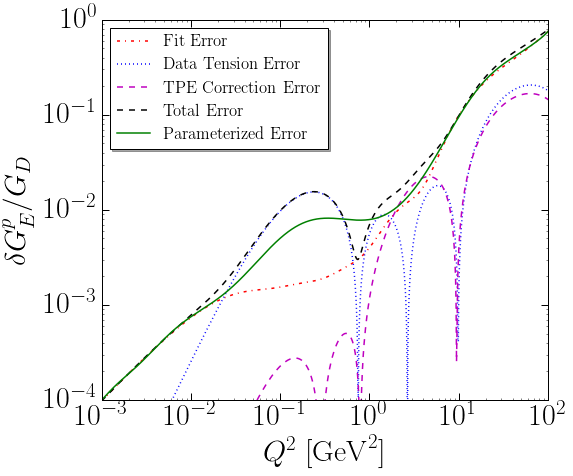

In [19]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(Q2, GE_err_fit, 'k-.', color='r',  label='Fit Error', linewidth=1.5)
axes.plot(Q2, GE_err_model, 'k:', color='b',  label='Data Tension Error', linewidth=1.5)
axes.plot(Q2, GE_err_tpe, 'k--', color='m',  label='TPE Correction Error', linewidth=1.5)
axes.plot(Q2, GE_err_sum, 'k--', color='black',  label='Total Error', linewidth=1.5)
axes.plot(Q2, GE_err_rh, 'k-', color='g',  label='Parameterized Error', linewidth=1.5)

axes.set_xlim(1e-3, 1e2)
axes.set_ylim(1e-4, 1e0)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$\delta G_E^p/G_{D}$', fontsize=30)

lg= axes.legend(loc='upper left', shadow='true', fontsize='small', numpoints=1)
#lg= axes.legend(loc='lower right', shadow='true', fontsize='small', numpoints=1)

axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

plt.savefig('GEp_Error_Curves.pdf',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves.eps',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves.png',bbox_inches='tight')

#plt.savefig('GEp_Error_Curves_seg7.pdf',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves_seg7.eps',bbox_inches='tight')
#plt.savefig('GEp_Error_Curves_seg7.png',bbox_inches='tight')

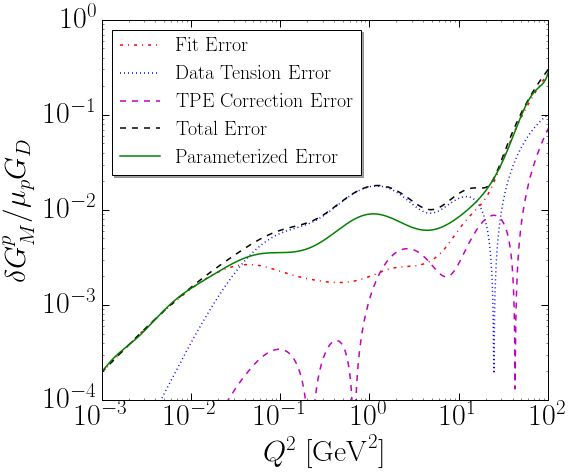

In [20]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(8,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GM/GD
axes.plot(Q2, GM_err_fit, 'k-.', color='r',  label='Fit Error', linewidth=1.5)
axes.plot(Q2, GM_err_model, 'k:', color='b',  label='Data Tension Error', linewidth=1.5)
axes.plot(Q2, GM_err_tpe, 'k--', color='m',  label='TPE Correction Error', linewidth=1.5)
axes.plot(Q2, GM_err_sum, 'k--', color='black',  label='Total Error', linewidth=1.5)
axes.plot(Q2, GM_err_rh, 'k-', color='g',  label='Parameterized Error', linewidth=1.5)

axes.set_xlim(1e-3, 1e2)
axes.set_ylim(1e-4, 1)
#axes.set_xlim(1e-6, 1e6)
#axes.set_ylim(1e-8, 1e2)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$\delta G_M^p/\mu_p G_{D}$', fontsize=30)

lg= axes.legend(loc='upper left', shadow='true', fontsize='medium', numpoints=1)
#lg= axes.legend(loc='lower right', shadow='true', fontsize='small', numpoints=1)

axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

plt.savefig('GMp_Error_Curves.pdf',bbox_inches='tight')
#plt.savefig('GMp_Error_Curves.eps',bbox_inches='tight')
#plt.savefig('GMp_Error_Curves.png',bbox_inches='tight')

#plt.savefig('GMp_Error_Curves_seg7.pdf',bbox_inches='tight')
#plt.savefig('GMp_Error_Curves_seg7.eps',bbox_inches='tight')
#plt.savefig('GMp_Error_Curves_seg7.png',bbox_inches='tight')

# Plot Central Values

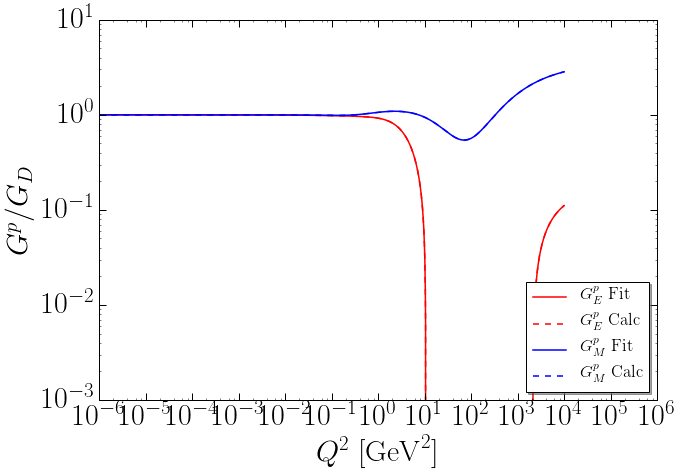

In [16]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(Q2, GE_fit/GEd, 'k-', color='r',  label='$G_E^p$ Fit', linewidth=1.5)
axes.plot(Q2, GE_fit_rh, 'k--', color='r',  label='$G_E^p$ Calc', linewidth=1.5)

axes.plot(Q2, GM_fit/GMd, 'k-', color='b',  label='$G_M^p$ Fit', linewidth=1.5)
axes.plot(Q2, GM_fit_rh, 'k--', color='b',  label='$G_M^p$ Calc', linewidth=1.5)

axes.set_xlim(1e-6, 1e6)
#axes.set_ylim(1e-8, 1e2)
axes.set_xscale('log')
axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$G^p/G_{D}$', fontsize=30)

#lg= axes.legend(loc='upper left', shadow='true', fontsize='small', numpoints=1)
lg= axes.legend(loc='lower right', shadow='true', fontsize='small', numpoints=1)

axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

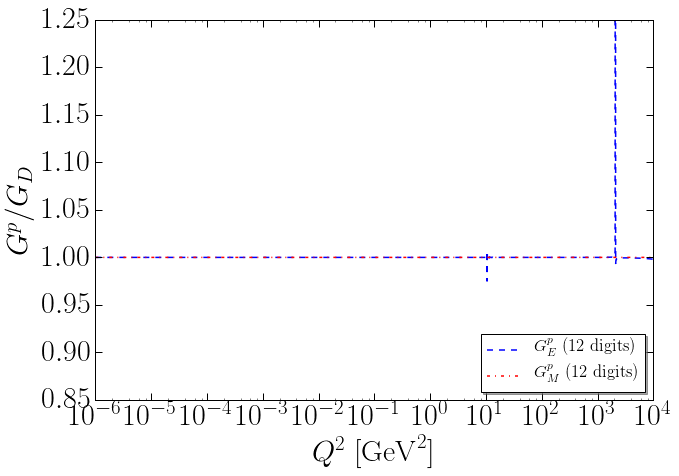

In [17]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)
ND=12
#######  Subplot for GE/GD.
axes.plot(Q2, GE_fit_rh/GE_fit_rat, 'k--', color='b',  label='$G_E^p$  (%d digits)'%ND, linewidth=1.5)
axes.plot(Q2, GM_fit_rh/GM_fit_rat, 'k-.', color='r',  label='$G_M^p$  (%d digits)'%ND, linewidth=1.5)

axes.set_xlim(1e-6, 1e4)
axes.set_ylim(0.85,1.25)
axes.set_xscale('log')
#axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$G^p/G_{D}$', fontsize=30)

#lg= axes.legend(loc='upper left', shadow='true', fontsize='small', numpoints=1)
lg= axes.legend(loc='lower right', shadow='true', fontsize='small', numpoints=1)

plt.savefig('proton_central_curve_%d_digits.pdf'%ND,bbox_inches='tight')
axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

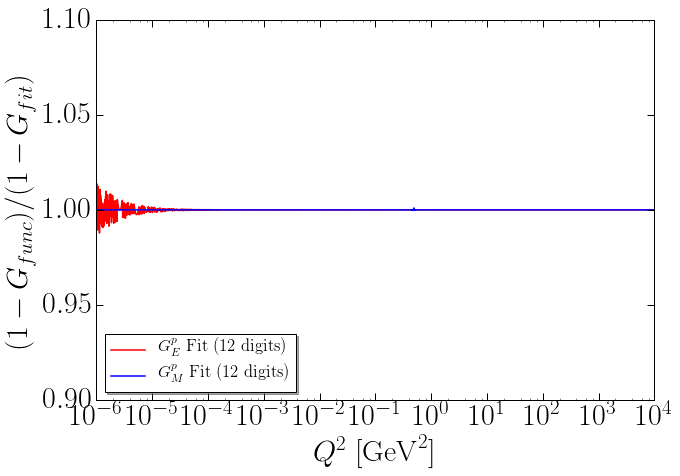

In [18]:
f1, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
f1.subplots_adjust(bottom=0.08, top=0.96, hspace=0.1)

#######  Subplot for GE/GD.
axes.plot(Q2, (1.-GE_fit_rh*GEd)/(1.-GE_fit), 'k-', color='r',  label='$G_E^p$ Fit (%d digits)'%ND, linewidth=1.5)

axes.plot(Q2, (1.-GM_fit_rh*GMd)/(1.-GM_fit), 'k-', color='b',  label='$G_M^p$ Fit (%d digits)'%ND, linewidth=1.5)

#axes.set_xlim(2000, 2200)
axes.set_ylim(0.9, 1.1)
axes.set_xscale('log')
#axes.set_yscale('log')

axes.set_xlabel('$Q^2$ $[\mathrm{GeV}^2]$', fontsize=30)
axes.set_ylabel('$(1-G_{func})/(1-G_{fit})$', fontsize=30)

lg= axes.legend(loc='lower left', shadow='true', fontsize='small', numpoints=1)
#lg= axes.legend(loc=' right', shadow='true', fontsize='small', numpoints=1)

axes.xaxis.set_tick_params(width=1, length=7)
axes.yaxis.set_tick_params(width=1, length=7)
plt.tick_params(labelsize=30)

plt.savefig('proton_central_curve_%d_digits_ratio.pdf'%ND,bbox_inches='tight')
